In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

In [12]:
source = 'T014'
df = pd.read_csv(f'{source}.tsv', header=None, delimiter='\t', usecols=[0])
df = df[0:10000]
df.reset_index(inplace=True, drop=True)
N = len(df)

f = 1000 #sampling rate
T = 1.0 / f
t = np.linspace(0.0, N * T, N)
y = df[0].to_numpy(dtype="float64")

print("# records:", N)

# records: 10000


**Plot Data**

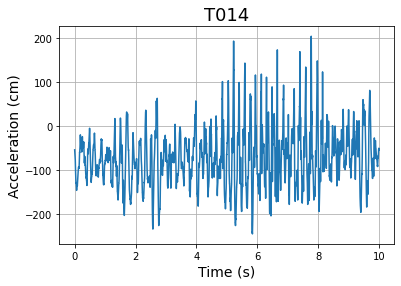

In [13]:
# plt.figure(figsize=(15,4), dpi=72)
plt.plot(t, y)
plt.grid()
plt.title(source, fontsize=18)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Acceleration (cm)', fontsize=14)
# plt.xlim(0, 10)
plt.show()


**Compute and Plot FFT**

In [14]:
def annot_max(x, y, ax=None):
    xmax = x[np.argmax(y)]
    ymax = y.max()
    # text= "x={:.2f}, y={:.2f}".format(xmax, ymax)
    text= "{:.2f}Hz".format(xmax)
    if not ax:
        ax=plt.gca()
    
    arrowprops = dict(
        arrowstyle="->", 
        connectionstyle="arc, angleA=-90, angleB=0, armA=0, armB=40, rad=0.0", 
        color="red"
        )
    bbox_props = dict(boxstyle="square, pad=0.3", fc="white", ec="red", lw=1)

    ax.annotate(
        text, 
        xy=(xmax, ymax), 
        xytext=(0.8, 0.7), 
        xycoords='data', 
        textcoords="axes fraction", 
        color='red', 
        fontsize='18',
        arrowprops = arrowprops, 
        bbox = bbox_props, 
        ha="right", 
        va="top"
        )


30


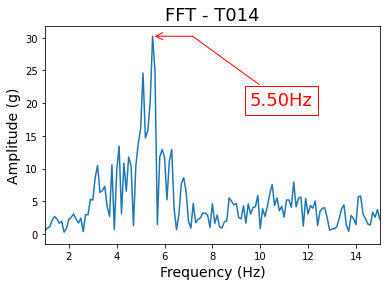

In [15]:
xf = np.linspace(0.0, 1.0/(2.0*T), np.int32(N/2))
yf = 2.0/N * np.abs(fft(y)[0:np.int32(N/2)])
yf[yf>100] = 0

# plt.figure(figsize=(15,4), dpi=72)
plt.plot(xf, yf)
# plt.grid()
plt.title(f'FFT - {source}', fontsize=18)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Amplitude (g)', fontsize=14)
plt.xlim(1, 15)
# plt.ylim(0, np.int32(np.max(yf)))
annot_max(xf, yf)
print(np.int32(np.max(yf)))
plt.show()
